<a href="https://colab.research.google.com/github/zakari90/machine-learning/blob/main/hierarchy_customer_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd

file_path = "/content/drive/MyDrive/hsoub ai/machine learning/unsupervised learning/shopping-data.csv"
df = pd.read_csv(file_path)
X = df.drop(columns=["CustomerID"])

X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [32]:
from sklearn.preprocessing import MinMaxScaler

data_scaler = MinMaxScaler(feature_range=(1,99))
# determine min and max
cc= data_scaler.fit(X)
# transfrom the data according to fite
TX=data_scaler.transform(X)

X['Income']=TX[:,0]

X['Score']=TX[:,1]

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z1 = linkage(X, method='single', metric='euclidean')
Z2 = linkage(X, method='complete', metric='euclidean')
Z3 = linkage(X, method='average', metric='euclidean')
Z4 = linkage(X, method='ward', metric='euclidean')

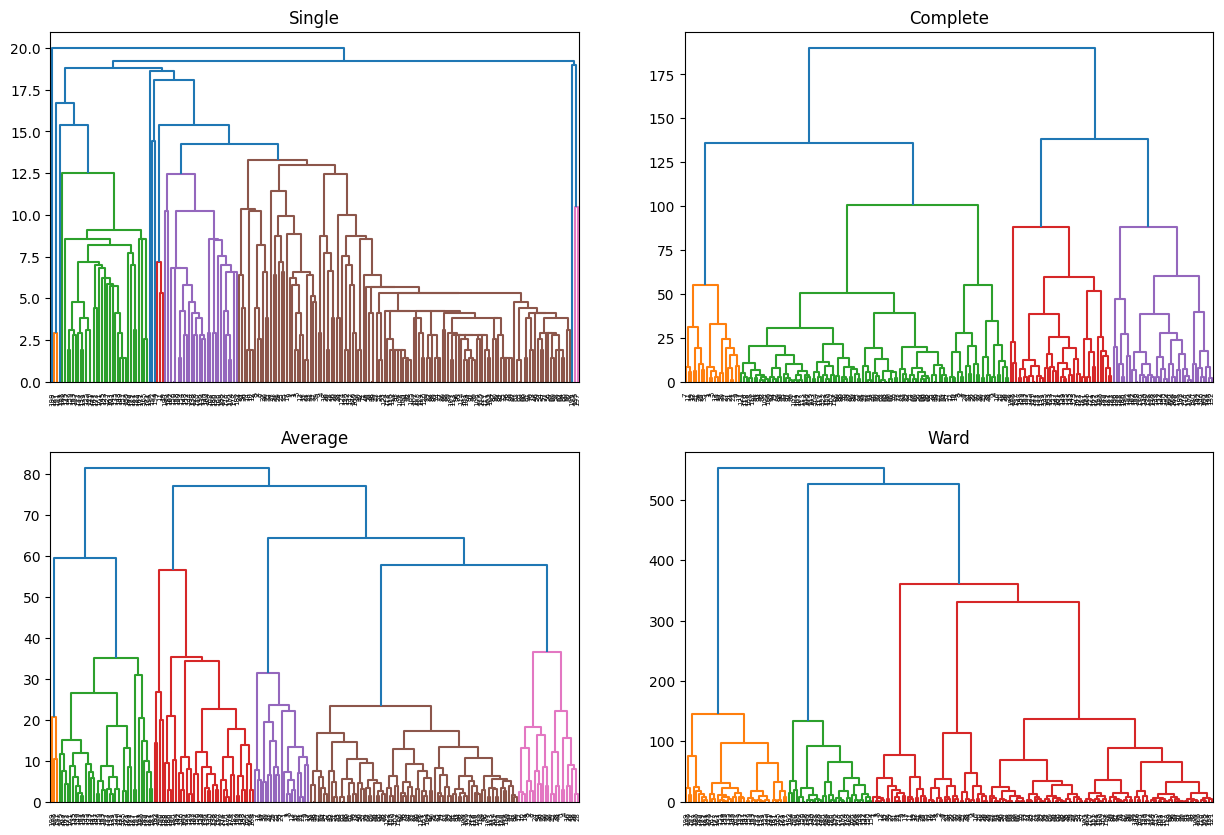

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plt.subplot(2,2,1), dendrogram(Z1), plt.title('Single')
plt.subplot(2,2,2), dendrogram(Z2), plt.title('Complete')
plt.subplot(2,2,3), dendrogram(Z3), plt.title('Average')
plt.subplot(2,2,4), dendrogram(Z4), plt.title('Ward')

plt.show()

In [35]:
from sklearn.cluster import AgglomerativeClustering

# Use the scaled features for clustering
Z1 = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Fit and predict using the scaled 'Income' and 'Score' columns from X
Z1.fit_predict(X[['Income', 'Score']])

print(Z1)
print(Z1.labels_)

AgglomerativeClustering(n_clusters=5)
[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 1 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 2 0 2 0 1 0 2 0 2 0 2 0 2 0 1 0 2 0 1 0
 2 0 2 0 2 0 2 0 2 0 2 0 1 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0]


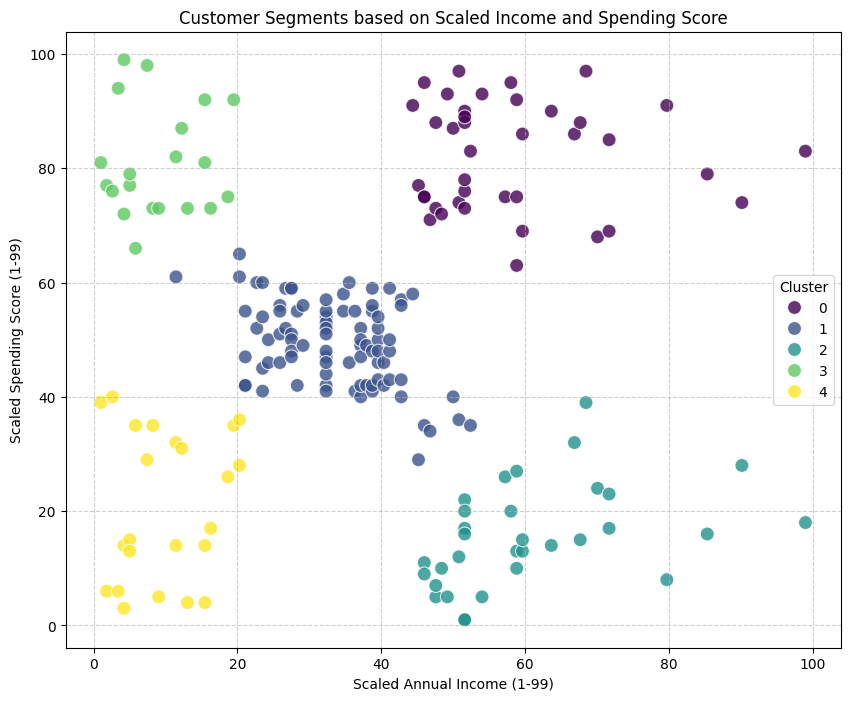

In [36]:
X['Cluster'] = Z1.labels_

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# Plot using the scaled features 'Income' and 'Score'
sns.scatterplot(x='Income', y='Score', hue='Cluster', data=X, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments based on Scaled Income and Spending Score')
plt.xlabel('Scaled Annual Income (1-99)')
plt.ylabel('Scaled Spending Score (1-99)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [43]:
cluster_map = pd.DataFrame()

cluster_map['CustomerID'] = df['CustomerID']

cluster_map['cluster'] = Z1.labels_

cluster_map[cluster_map.cluster == 1]

,CustomerID,cluster
27,28,1
43,44,1
45,46,1
46,47,1
47,48,1
...,...,...
126,127,1
132,133,1
142,143,1
146,147,1
